# Effectiveness of thrombolysis and thrombectomy in all arrivals of non-mild stroke - discharge mRS 0-2: S-Learner

A 'S-Learner' is a single model that predicts outcome based on patient characteristics and treatment received. It should include all confounders (thoughts factors that affect both outcome and propensity to treat).

## Selection criteria

* Stroke type = infarction
* No recorded use of perfusion imaging
* Stroke severity > 5 (or labelled as LVO)

## Outcome of interest

* Discharge mRS 0-2.

## Key features of interest

* Onset to thrombolysis time
* Onset to thrombectomy time

## Adjustment features used:

* Prior disability
* Stroke severity
* Age
* Congestive heart failure
* Hypertension
* Diabetes
* Atrial fibrillation anticoagulant
* Any atrial fibrillation diagnosis (existing or new)
* Stroke team
* Ethnicity

## Methodology steps

* Select patients by above criteria
* Select features by above criteria
* Split data in 5 sets, where 80% of data is used to train a model, and tets results are generated for the remaining 20% (each patient is in a single test set)
* Train 5 models
* For each model get outcome results for the tets set
* For each model, for patients treated with thrombolysis or thrombectomy, get counterfactual outcomes if they had no treatment
* Calculate the difference between actual outcome and (counterfactual) no-treatment outcomes for treated patients
* Analyse resuls for patients who 1) received thrombectomy only, 2) thrombolysis only, 3) thrombolysis or thrombectomy *

*Note - though the analysis is by different groups, the models are fitted to all groups (no treatment, thrombolysis alone, thrombectomy alone, thrombolysis + thrombectomy).

## Define conditions

In [1]:
mrs_target = 2 # Model will set y as being less than or equal to this value
save_prefix = f"01b_all_non_mild_mrs_{mrs_target}"

CUTOFF = 270

## Load modules

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from xgboost import XGBRegressor

# Disable warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

## Define the features to be used in the model

In [3]:
# Non-categorical X fields (used in model)
non_categorical_features = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'transfer_used'
]

# Categorical X fields (used in model)
categorical_features = [
    'treatment_group',
    'stroke_team',
    'ethnicity',
]

X_fields = non_categorical_features + categorical_features

# Additional info cols (not used in model, but used in analysis)
info_cols = [
    'perfusion_imaging_used',
    'onset_to_thrombolysis_time',
    'onset_to_thrombectomy_time',
    'thrombectomy_centre'
]


## Load and filter data

In [4]:
data = pd.read_csv("../../data/sam3/cleaned_data_anon_teams.csv", low_memory=False)

# Ensure categorical columns are pandas categorical dtype for XGBoost
for col in categorical_features:
    if col in data.columns:
        data[col] = data[col].replace("", "Empty")
        data[col] = data[col].astype("category")

# Ensure non-categorical columns are numeric
for col in non_categorical_features:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Limit to stroke severity  > 5 
data = data[((data["stroke_severity"] > 5) | data["lvo"] == 1)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)
data["onset_to_thrombectomy_time"] = data["onset_to_thrombectomy_time"].fillna(99999)

# Remove rows where thrombolysis is after thrombectomy (if both are present)
both_treatments = (
    (data["onset_to_thrombolysis_time"] < 99999)
    & (data["onset_to_thrombectomy_time"] < 99999)
)
thrombolysis_after_thrombectomy = (
    data["onset_to_thrombolysis_time"] > data["onset_to_thrombectomy_time"]
)
data = data[~(both_treatments & thrombolysis_after_thrombectomy)]

print(f"Final data shape: {data.shape}")

# Remove rows with missing stroke_severity
data = data.dropna(subset=["stroke_severity"])

# Treatment counts
num_thrombectomy = data['thrombectomy'].sum()
print(f"Number of patients with thrombectomy: {num_thrombectomy}")

num_both = (
    (data["thrombolysis"] == 1)
    & (data["thrombectomy"] == 1)
).sum()
print(f"Number of patients with both thrombolysis and thrombectomy: {num_both}")

num_only_thrombectomy = (
    (data["thrombectomy"] == 1)
    & (data["thrombolysis"] != 1)
).sum()
print(f"Number of patients with only thrombectomy: {num_only_thrombectomy}")

num_thrombolysis = (data["thrombolysis"] == 1).sum()
print(f"Number of patients with thrombolysis: {num_thrombolysis}")

num_only_thrombolysis = (
    (data["thrombolysis"] == 1)
    & (data["thrombectomy"] != 1)
).sum()
print(f"Number of patients with only thrombolysis: {num_only_thrombolysis}")


Initial data shape: (452863, 72)
Final data shape: (151300, 72)
Number of patients with thrombectomy: 13900
Number of patients with both thrombolysis and thrombectomy: 7036
Number of patients with only thrombectomy: 6864
Number of patients with thrombolysis: 38570
Number of patients with only thrombolysis: 31534


In [5]:
# Add treatment columns

TIME_THROMBOLYSIS = "onset_to_thrombolysis_time"
TIME_THROMBECTOMY = "onset_to_thrombectomy_time"

def add_treatment_columns(data):
    """
    Add treatment column based on use and time of thrombolysis only.
    Use CUTOFF to determine whether treatment is early or late.
    Sentinel value of 99999 means no treatment. 
    """

    data["treatment_group"] = "neither"

    # Early thrombolysis only
    data.loc[(data['thrombolysis'] == 1) & (data['thrombectomy'] == 0) & 
            (data[TIME_THROMBOLYSIS] <CUTOFF),
            "treatment_group"] = "early_thrombolysis_only"

    # Late thrombolysis only
    data.loc[(data['thrombolysis'] == 1) & (data['thrombectomy'] == 0) & 
             (data[TIME_THROMBOLYSIS] >= CUTOFF) & (data[TIME_THROMBOLYSIS] != 99999),
             "treatment_group"] = "late_thrombolysis_only"

    # Thrombolysis only, unknown time
    data.loc[(data['thrombolysis'] == 1) & (data['thrombectomy'] == 0) & 
             (data[TIME_THROMBOLYSIS] == 99999),
             "treatment_group"] = "thrombolysis_only_unknown_time"

    # Early thrombectomy only
    data.loc[(data['thrombolysis'] == 0) & (data['thrombectomy'] == 1) & 
             (data[TIME_THROMBECTOMY] < CUTOFF),
             "treatment_group"] = "early_thrombectomy_only"

    # Late thrombectomy only
    data.loc[(data['thrombolysis'] == 0) & (data['thrombectomy'] == 1) & 
             (data[TIME_THROMBECTOMY] >= CUTOFF) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_thrombectomy_only"

    # Thrombectomy only, unknown time
    data.loc[(data['thrombolysis'] == 0) & (data['thrombectomy'] == 1) & 
             (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "thrombectomy_only_unknown_time"

    # Early thrombolysis and early thrombectomy
    data.loc[(data['thrombolysis'] == 1) & (data['thrombectomy'] == 1) &
             (data[TIME_THROMBOLYSIS] < CUTOFF) & (data[TIME_THROMBECTOMY] < CUTOFF),
             "treatment_group"] = "early_both"

    # Early thrombolysis and late thrombectomy
    data.loc[(data['thrombolysis'] == 1) & (data['thrombectomy'] == 1) &
             (data[TIME_THROMBOLYSIS] < CUTOFF) & 
             (data[TIME_THROMBECTOMY] >= CUTOFF) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "early_thrombolysis_late_thrombectomy"

    # Late both thrombolysis and thrombectomy
    data.loc[(data['thrombolysis'] == 1) & (data['thrombectomy'] == 1) &
            (data[TIME_THROMBOLYSIS] >= CUTOFF) & (data[TIME_THROMBOLYSIS] != 99999) &
            (data[TIME_THROMBECTOMY] >= CUTOFF) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_both"

    # Thrombolysis and thrombectomy, any unknown time
    data.loc[(data['thrombolysis'] == 1) & (data['thrombectomy'] == 1) &
             ((data[TIME_THROMBOLYSIS] == 99999) | (data[TIME_THROMBECTOMY] == 99999)),
             "treatment_group"] = "both_unknown_time"
    

    return data

data = add_treatment_columns(data)

data["patient_id"] = np.arange(len(data))

# Save to output
data.to_csv(
    "./output/01b_thrombolysis_thrombectomy_with_late_treatment_input.csv", index=False)

## Descriptive stats

In [6]:
# Stats to show
DESCRIPTIVE_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'perfusion_imaging_used',
    'transfer_used',
    'onset_to_thrombolysis_time',
    'onset_to_thrombectomy_time'
]

# Order of treatment groups for descriptive statistics table
column_order = [
    'neither',
    'early_thrombolysis_only',
    'late_thrombolysis_only',
    'thrombolysis_only_unknown_time',
    'early_thrombectomy_only',
    'late_thrombectomy_only',
    'thrombectomy_only_unknown_time',
    'early_both',
    'early_thrombolysis_late_thrombectomy',
    'late_both',
    'both_unknown_time'
]
# Create descriptive statistics table by treatment group
descriptive_stats = (
    data.groupby("treatment_group")[DESCRIPTIVE_FEATURES]
    .describe()
    .T
)

# Reorder treatment-group columns safely
descriptive_stats = descriptive_stats.reindex(columns=column_order).round(2)

# Create two columns for index
descriptive_stats = descriptive_stats.reset_index()
# Rename the columns for clarity
descriptive_stats.columns = ["feature", "statistic"] + list(descriptive_stats.columns[2:])

descriptive_stats.to_csv(f"./output/{save_prefix}_descriptive_stats_by_treatment_group.csv", index=False)
descriptive_stats

,feature,statistic,neither,early_thrombolysis_only,late_thrombolysis_only,thrombolysis_only_unknown_time,early_thrombectomy_only,late_thrombectomy_only,thrombectomy_only_unknown_time,early_both,early_thrombolysis_late_thrombectomy,late_both,both_unknown_time
0,prior_disability,count,105746.00,28482.00,2410.00,642.00,1318.00,4529.00,1017.00,2739.00,3572.00,568.00,157.00
1,prior_disability,mean,1.70,1.00,0.98,0.94,0.76,0.62,0.55,0.44,0.41,0.49,0.56
2,prior_disability,std,1.55,1.31,1.28,1.23,0.90,0.85,0.83,0.75,0.74,0.76,1.03
3,prior_disability,min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,prior_disability,25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,onset_to_thrombectomy_time,min,99999.00,99999.00,99999.00,99999.00,0.00,270.00,99999.00,75.00,270.00,309.00,99999.00
92,onset_to_thrombectomy_time,25%,99999.00,99999.00,99999.00,99999.00,179.00,371.00,99999.00,181.00,305.00,449.50,99999.00
93,onset_to_thrombectomy_time,50%,99999.00,99999.00,99999.00,99999.00,212.00,543.00,99999.00,215.00,348.50,574.50,99999.00
94,onset_to_thrombectomy_time,75%,99999.00,99999.00,99999.00,99999.00,241.75,863.00,99999.00,242.50,418.00,743.00,99999.00


## Grouped timings

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = data[X_fields]
y = (data['discharge_disability'] <= mrs_target).astype(int)

train_X_sets = []
train_y_sets = []
test_X_sets = []
test_y_sets = []
info_set = []


for train_index, test_index in skf.split(X, y):
    train_X, test_X = X.iloc[train_index], X.iloc[test_index]
    train_y, test_y = y.iloc[train_index], y.iloc[test_index]
    info = data.iloc[test_index][info_cols]    
    train_X_sets.append(train_X)
    train_y_sets.append(train_y)
    test_X_sets.append(test_X)
    test_y_sets.append(test_y)

    # Enforce categorical dtype
    for cat_feature in categorical_features:
        train_X[cat_feature] = train_X[cat_feature].astype('category')
        test_X[cat_feature] = test_X[cat_feature].astype('category')


    # Enforce numeric dtype for continuous/binary features
    for col in non_categorical_features:
        train_X[col] = pd.to_numeric(train_X[col], errors="coerce").astype("float32")
        test_X[col] = pd.to_numeric(test_X[col], errors="coerce").astype("float32")

    info_set.append(info)

In [8]:
models = []
test_y_pred_probas = []
test_y_preds = []

for split in range(5):
    # Get data for this split
    train_X = train_X_sets[split]
    train_y = train_y_sets[split]
    test_X = test_X_sets[split]
    test_y = test_y_sets[split]
    # Ensure categorical features are treated as categorical
    for cat_feature in categorical_features:
        train_X[cat_feature] = train_X[cat_feature].astype('category')
        test_X[cat_feature] = test_X[cat_feature].astype('category')
    # Ensure non-categorical features are treated as numeric
    for num_feature in non_categorical_features:
        train_X[num_feature] = pd.to_numeric(train_X[num_feature], errors='coerce').astype('float32')
        test_X[num_feature] = pd.to_numeric(test_X[num_feature], errors='coerce').astype('float32')
    # Get data for weighting
    pos = train_y.sum()
    neg = len(train_y) - pos
    model = XGBClassifier(
        enable_categorical=True,
        verbosity=0,
        seed=42,
        eval_metric='logloss',
        # Scale weight manually adjusted so predictive positive rate
        # matched actual positive rate
        scale_pos_weight=(neg / pos) * 0.49
    )
    # Train model
    # Make local copies to avoid chained-assignment issues
    train_X = train_X.copy()
    test_X = test_X.copy()

    # Ensure all string/object columns (e.g., treatment_group) are categorical
    cat_cols = train_X.select_dtypes(include=["object", "category"]).columns

    for col in cat_cols:
        train_X[col] = train_X[col].astype("category")
        # Align test categories to training categories
        test_X[col] = pd.Categorical(test_X[col], categories=train_X[col].cat.categories)

    model.fit(train_X, train_y)
    models.append(model)
    # Evaluate model with AUC and balanced accuracy
    y_pred_proba = model.predict_proba(test_X)[:, 1]
    y_pred = model.predict(test_X)
    auc = roc_auc_score(test_y, y_pred_proba)
    bal_acc = balanced_accuracy_score(test_y, y_pred)
    test_y_pred_probas.append(y_pred_proba)
    test_y_preds.append(y_pred)
    print(f"Split {split + 1}: AUC = {auc:.4f}, Balanced Accuracy = {bal_acc:.4f}")

Split 1: AUC = 0.8236, Balanced Accuracy = 0.7145
Split 2: AUC = 0.8282, Balanced Accuracy = 0.7155
Split 3: AUC = 0.8270, Balanced Accuracy = 0.7134
Split 4: AUC = 0.8286, Balanced Accuracy = 0.7223
Split 5: AUC = 0.8237, Balanced Accuracy = 0.7152


In [9]:
# Check predicted vs actual positive rates
for split in range(5):
    test_y = test_y_sets[split]
    y_pred_proba = test_y_pred_probas[split]
    y_pred = test_y_preds[split]
    
    actual_pos_rate = test_y.mean()
    predicted_pos_rate = y_pred.mean()
    
    print(f"Split {split + 1}: Actual positive rate = {actual_pos_rate:.4f}, Predicted positive rate = {predicted_pos_rate:.4f}")

Split 1: Actual positive rate = 0.2757, Predicted positive rate = 0.2780
Split 2: Actual positive rate = 0.2758, Predicted positive rate = 0.2738
Split 3: Actual positive rate = 0.2758, Predicted positive rate = 0.2691
Split 4: Actual positive rate = 0.2758, Predicted positive rate = 0.2760
Split 5: Actual positive rate = 0.2758, Predicted positive rate = 0.2742


## SHAP for model

Use first model.

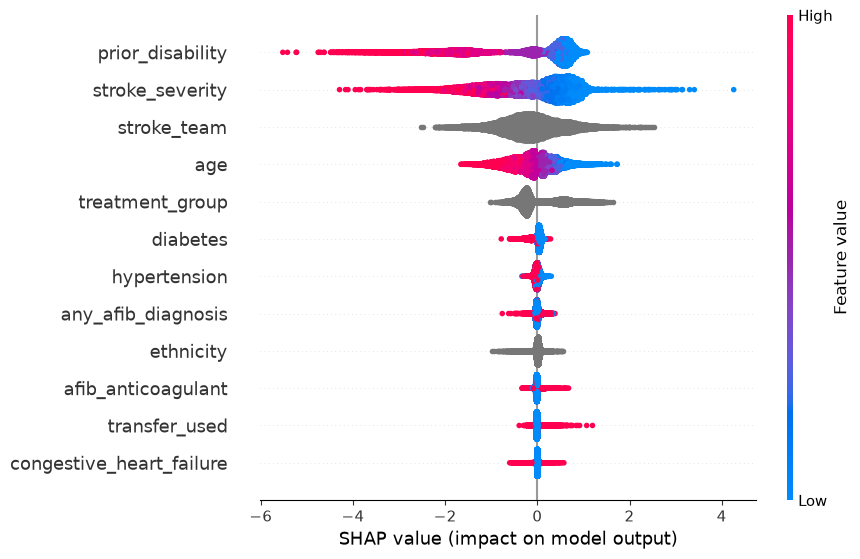

In [10]:
# Use explainer without background data due to errors occuring
explainer = shap.TreeExplainer(models[0], feature_perturbation="tree_path_dependent")

# Use first test set for SHAP values
shap_values = explainer(test_X_sets[0])

shap.plots.beeswarm(shap_values, max_display=99, show=False)
plt.savefig(
    f"./output/{save_prefix}_outcome_shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [11]:
shap_values_df = pd.DataFrame(shap_values.values, columns=X_fields)
shap_values_df.to_csv(f"./output/{save_prefix}_outcome_shap_values.csv", index=False)
shap_values_df

,prior_disability,stroke_severity,age,congestive_heart_failure,hypertension,diabetes,afib_anticoagulant,any_afib_diagnosis,transfer_used,treatment_group,stroke_team,ethnicity
0,0.491723,-0.428942,0.609275,-0.001897,0.036685,0.023963,-0.084278,-0.074372,-0.022878,0.475326,0.134124,0.008313
1,-1.883628,0.316841,-1.150452,-0.009713,0.033822,-0.000747,0.014364,-0.027395,0.006356,0.482004,-0.754558,-0.005771
2,-2.651953,0.579220,-0.312349,0.006889,0.001436,0.008437,-0.108287,0.037516,-0.001904,-0.272746,-1.530059,-0.045763
3,0.192571,-0.458945,-0.151327,0.028241,0.006009,0.020803,-0.070503,0.123891,-0.003153,-0.342192,0.225681,0.027891
4,0.392361,-0.382265,0.098950,0.003196,-0.029390,0.023935,0.073301,0.026110,-0.030792,-0.467652,0.210165,-0.058117
...,...,...,...,...,...,...,...,...,...,...,...,...
30231,0.586383,0.471801,0.607997,-0.002132,-0.082456,0.030811,-0.012435,-0.022336,-0.001736,-0.339129,-0.578562,-0.370096
30232,0.796285,0.509098,-0.824809,0.002184,0.001826,0.043160,0.006184,0.007432,0.005822,0.520294,-0.321224,0.035044
30233,-1.100200,-1.339153,-0.314193,0.000285,0.012150,-0.171605,-0.012223,0.005233,0.013972,-0.285652,-0.332217,-0.069067
30234,-2.225116,-0.585546,0.009885,-0.005321,-0.008598,0.023510,0.006926,-0.004869,-0.013445,0.437851,0.002977,0.001834


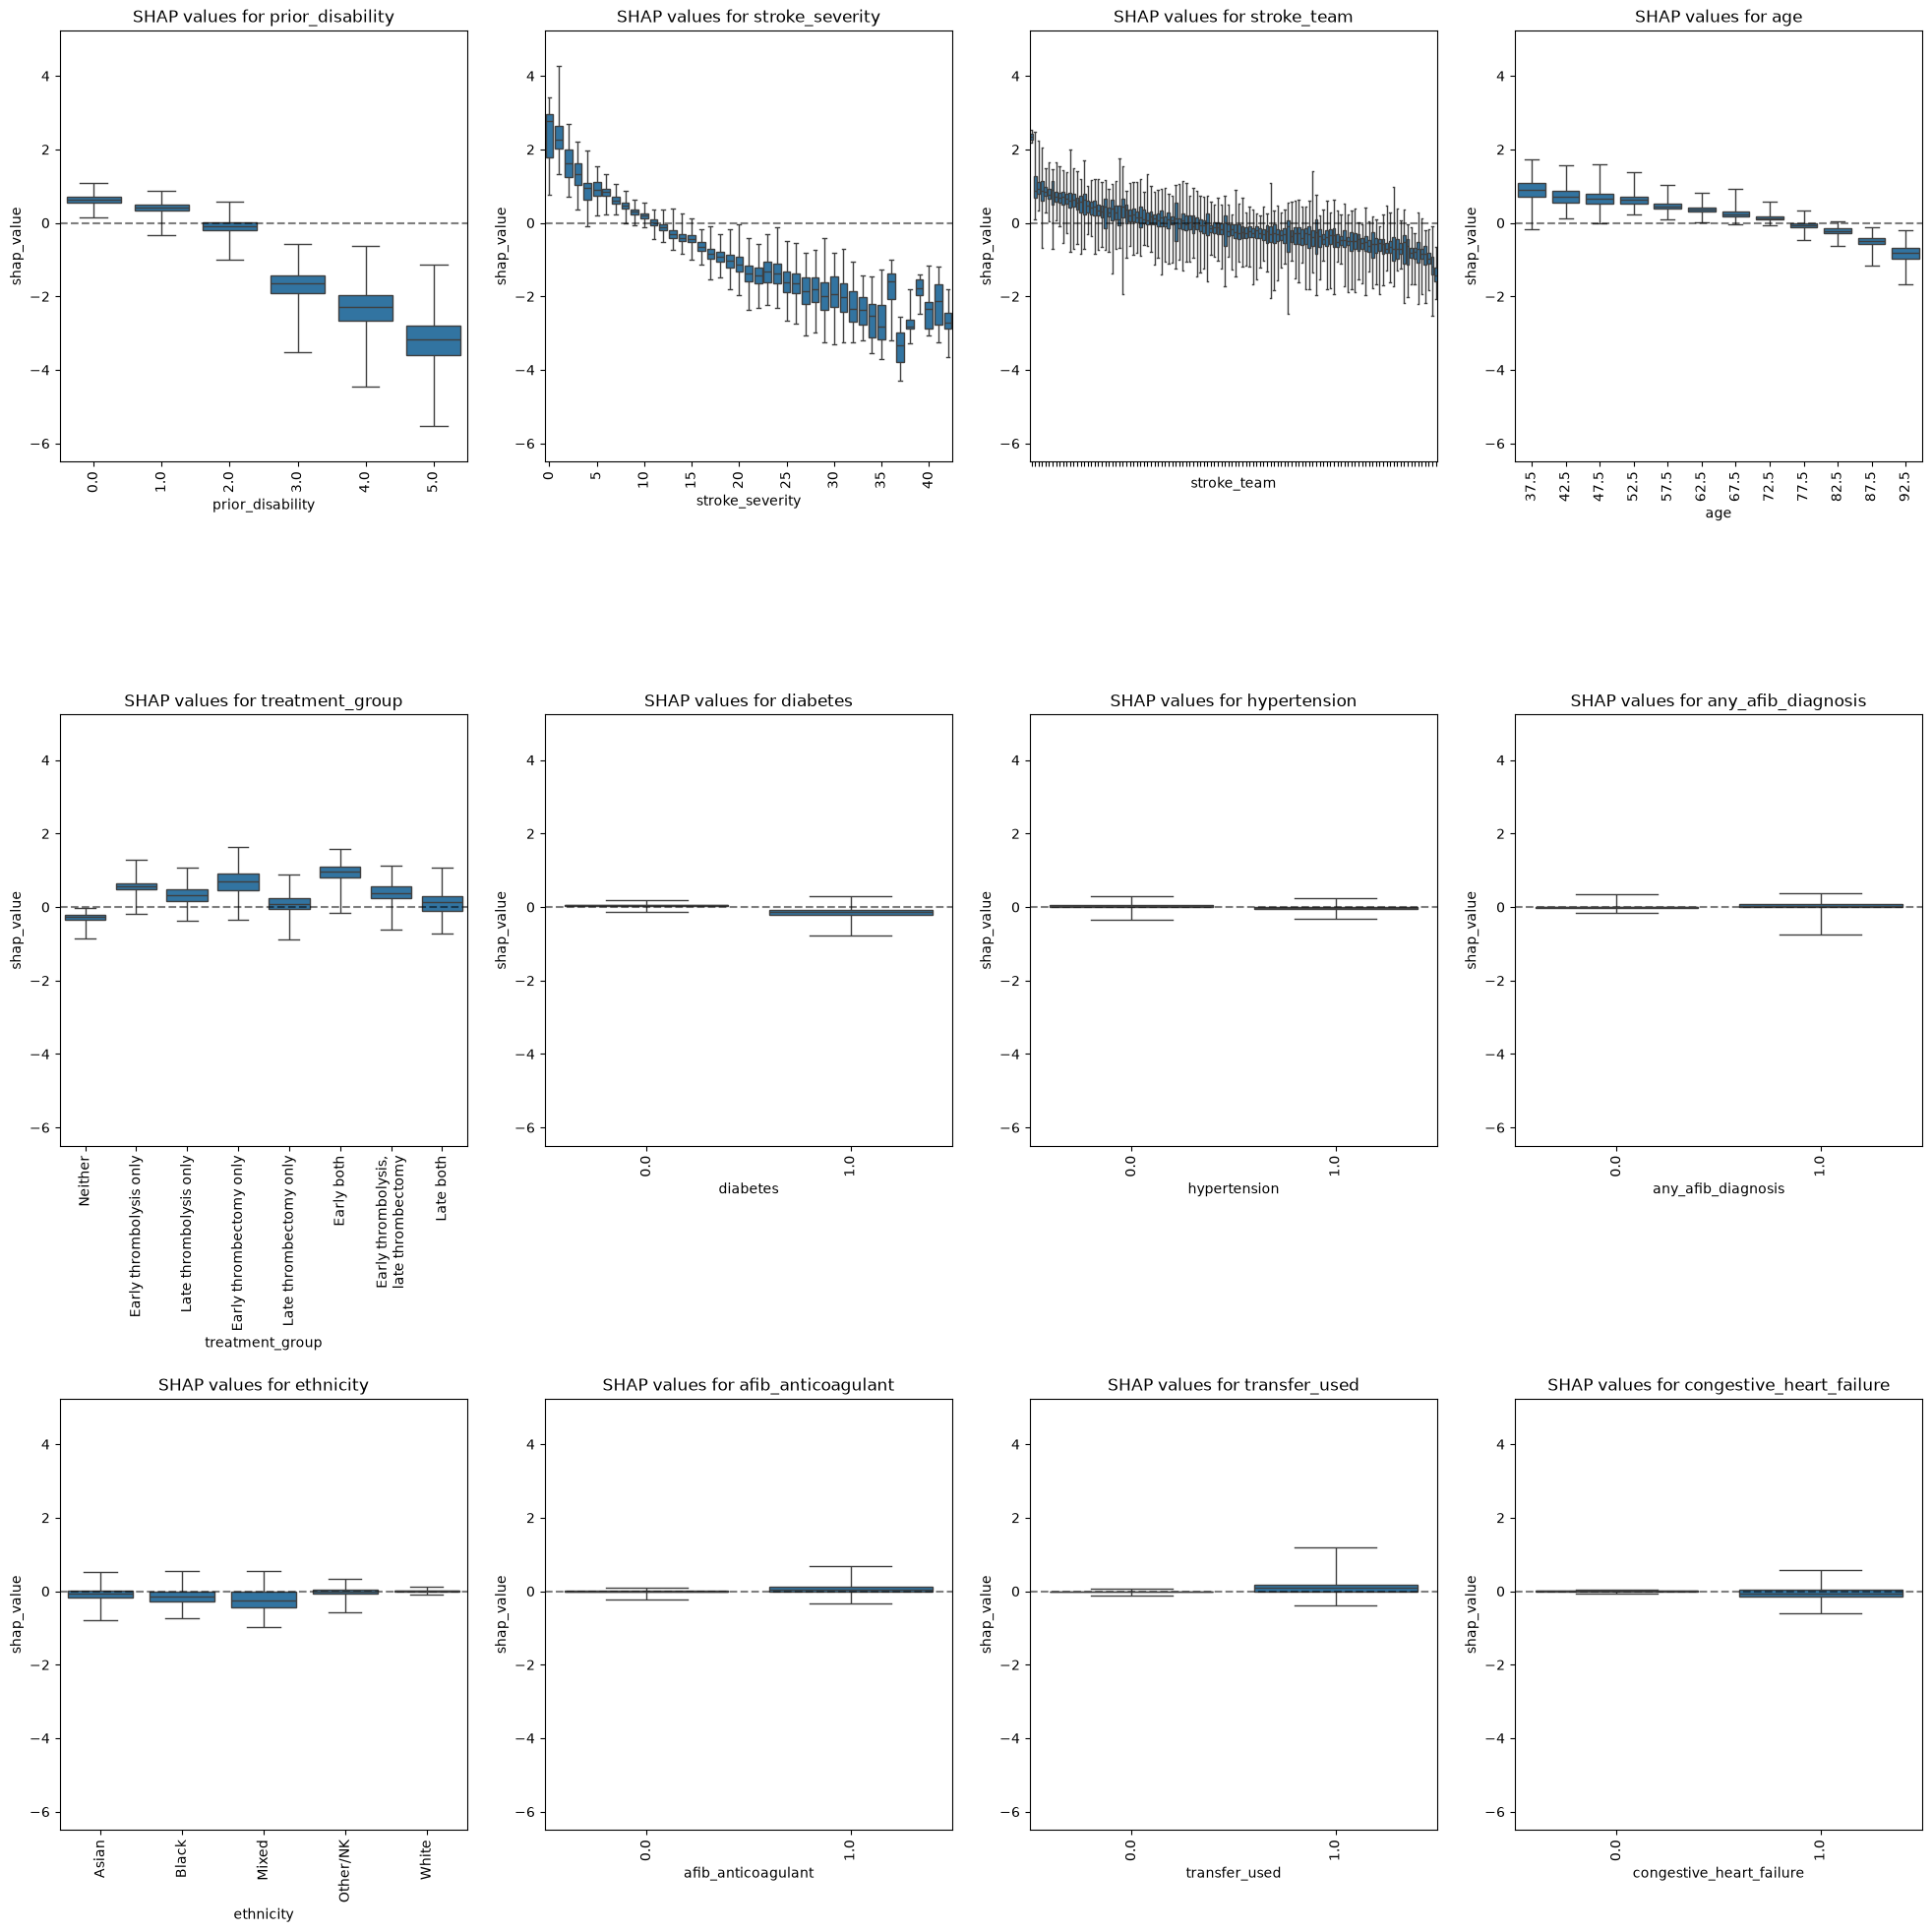

In [12]:
rename_dict = {
    "neither": "Neither",
    "early_thrombolysis_only": "Early thrombolysis only",
    "late_thrombolysis_only": "Late thrombolysis only",
    "early_thrombectomy_only": "Early thrombectomy only",
    "late_thrombectomy_only": "Late thrombectomy only",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both"
}

# Store index in ordered_arms for later use in plotting
ordered_arms = list(rename_dict.keys())

# Get average absolute SHAP values for each feature
mean_abs_shap_values = shap_values_df.abs().mean().sort_values(ascending=False)

# Reorder features_to_plot based on mean absolute SHAP values
features_to_plot = mean_abs_shap_values.index.tolist()

# Create a 3 x 4 grid of SHAP summary plots for the top features
fig, axes = plt.subplots(3, 4, figsize=(20, 20))

for i, feature in enumerate(features_to_plot):
    row = i // 4
    col = i % 4

    # Get feature and SHAP values for the feature, and plot a boxplot of SHAP for each feature value
    shap_values_feature = shap_values[:, feature].values
    feature_values = test_X_sets[0][feature].values

    # Create a DataFrame for plotting
    plot_df = pd.DataFrame({
        "feature_value": feature_values,
        "shap_value": shap_values_feature
    })

    # If the feature is stroke_team, sort by average SHAP value
    if feature == "stroke_team":
        avg_shap_values = plot_df.groupby("feature_value")["shap_value"].mean().sort_values(ascending=False)
        sorted_order = avg_shap_values.index.tolist()
        plot_df["feature_value"] = pd.Categorical(
            plot_df["feature_value"],
            categories=sorted_order,
            ordered=True
        )

    # Use rename dict to rename treatment_group values for plotting
    if feature == "treatment_group":
        sorted_order = [rename_dict.get(k, k) for k in ordered_arms]
        # Convert to string first to avoid Categorical setitem error
        plot_df["feature_value"] = (
            plot_df["feature_value"].astype(str).map(
                lambda x: rename_dict.get(x, x)
            )
        )
        plot_df["feature_value"] = pd.Categorical(
            plot_df["feature_value"],
            categories=sorted_order,
            ordered=True,
        )

    # Create a boxplot of SHAP values for each feature value
    sns.boxplot(
        x="feature_value",
        y="shap_value",
        data=plot_df,
        ax=axes[row, col],
        whis=(0, 100)
    )
    axes[row, col].set_title(f"SHAP values for {feature}")
    axes[row, col].tick_params(axis="x", rotation=90)

    # If the feature is stroke_team remove x tick labels for clarity
    if feature == "stroke_team":
        axes[row, col].set_xticklabels([])

    # If the feature is stroke_severity, set x ticks to 0-42, and make an integer scale
    if feature == "stroke_severity":
        axes[row, col].set_xticks(range(0, 43, 5))
        axes[row, col].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}'))

    # Replace x label with feature name
    axes[row, col].set_xlabel(feature)

    # Add line at y=0
    axes[row, col].axhline(y=0, color='black', linestyle='--', alpha=0.5)

    # Scale all y axes to the same range based on the min and max SHAP values across all features
    min_shap = shap_values_df.min().min()
    max_shap = shap_values_df.max().max()
    axes[row, col].set_ylim(min_shap - 0.1 * (max_shap - min_shap), max_shap + 0.1 * (max_shap - min_shap))

# Hide any unused subplot axes
for j in range(len(features_to_plot), axes.size):
    axes.flat[j].axis("off")

plt.tight_layout(pad=2)
plt.savefig(f"./output/{save_prefix}_shap_box_plots_outcome.png", dpi=300, bbox_inches="tight")
plt.show()

## Estimate counter-factuals

In [13]:
counter_factuals = []

for split in range(5):
    model = models[split]
    info = info_set[split]
    test_X = test_X_sets[split]
    test_X["treatment_group"]= test_X["treatment_group"].astype("category")

    # Predict probabilities for the test set
    predicted_proba = model.predict_proba(test_X)[:, 1]

    # Change treatment_group to "neither" for counterfactual prediction
    test_X_cf = test_X.copy(deep=True)
    # Set to 'neither' but keep the same dtype and categories
    test_X_cf["treatment_group"] = pd.Categorical(
        ["neither"] * len(test_X_cf),
        categories=test_X["treatment_group"].cat.categories,
        ordered=test_X["treatment_group"].cat.ordered
    )
    # Predict probabilities for the counterfactual set
    predicted_proba_cf = model.predict_proba(test_X_cf)[:, 1]

    # Store X, info, predicted probabilities, and counterfactual probabilities in a DataFrame
    cf_df = test_X.copy()
    cf_df = pd.concat([cf_df, info], axis=1)
    cf_df["predicted_proba"] = predicted_proba
    cf_df["predicted_proba_cf"] = predicted_proba_cf
    cf_df["predicted_proba_shift"] = cf_df["predicted_proba"] - cf_df["predicted_proba_cf"]

    counter_factuals.append(cf_df)

# Concatenate all counterfactual DataFrames into a single DataFrame
counter_factuals_df = pd.concat(counter_factuals, ignore_index=True)

# Save the counterfactual DataFrame to a CSV file
counter_factuals_df.to_csv(f"./output/{save_prefix}_counterfactual_predictions.csv", index=False)

In [14]:
# Calculate mean, SD, and 95% CI of CATE for each treatment arm
counter_factual_summary = counter_factuals_df.groupby("treatment_group")["predicted_proba_shift"].agg(["mean", "std", "count"])
counter_factual_summary["95% CI lower"] = counter_factual_summary["mean"] - 1.96 * counter_factual_summary["std"] / np.sqrt(counter_factual_summary["count"])
counter_factual_summary["95% CI upper"] = counter_factual_summary["mean"] + 1.96 * counter_factual_summary["std"] / np.sqrt(counter_factual_summary["count"])

ordered_arms = [
    "early_thrombolysis_only",
    "late_thrombolysis_only",
    "thrombolysis_only_unknown_time",
    "early_thrombectomy_only",
    "late_thrombectomy_only",
    "thrombectomy_only_unknown_time",
    "early_both",
    "early_thrombolysis_late_thrombectomy",
    "late_both",
    "both_unknown_time"
]
counter_factual_summary = counter_factual_summary.reindex(ordered_arms).round(4)
counter_factual_summary

,mean,std,count,95% CI lower,95% CI upper
treatment_group,,,,,
early_thrombolysis_only,0.1571,0.1151,28482,0.1558,0.1584
late_thrombolysis_only,0.1025,0.1348,2410,0.0971,0.1079
thrombolysis_only_unknown_time,0.0965,0.1606,642,0.0841,0.1090
early_thrombectomy_only,0.2098,0.1804,1318,0.2000,0.2195
late_thrombectomy_only,0.0824,0.1278,4529,0.0787,0.0861
thrombectomy_only_unknown_time,0.0643,0.1383,1017,0.0558,0.0728
early_both,0.2788,0.1659,2739,0.2726,0.2850
early_thrombolysis_late_thrombectomy,0.1417,0.1422,3572,0.1371,0.1464
late_both,0.1116,0.1912,568,0.0959,0.1273


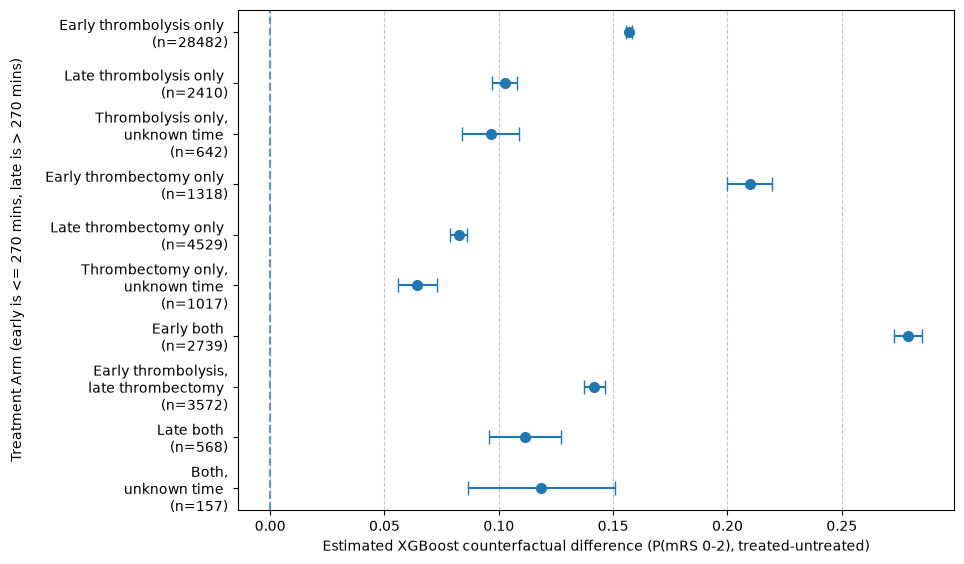

In [15]:
rename_dict = {
    "early_thrombolysis_only": "Early thrombolysis only",
    "late_thrombolysis_only": "Late thrombolysis only",
    "thrombolysis_only_unknown_time": "Thrombolysis only,\nunknown time",
    "early_thrombectomy_only": "Early thrombectomy only",
    "late_thrombectomy_only": "Late thrombectomy only",
    "thrombectomy_only_unknown_time": "Thrombectomy only,\nunknown time",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both",
    "both_unknown_time": "Both,\nunknown time"
}
# Add n values to the y tick labels
n_values = counter_factual_summary["count"].astype(int).to_dict()
rename_dict = {k: f"{v} \n(n={n_values.get(k, 0)})" for k, v in rename_dict.items()}

fig, ax = plt.subplots(figsize=(10, 6))
# Plot the mean prob shift with error bars for 95% CI
ax.errorbar(
    y=range(len(counter_factual_summary.index) - 1, -1, -1),
    x=counter_factual_summary["mean"],
    xerr=[
        counter_factual_summary["mean"] - counter_factual_summary["95% CI lower"],
        counter_factual_summary["95% CI upper"] - counter_factual_summary["mean"],
    ],
    fmt="o",
    markersize=7,  # increase point size
    capsize=5,
    label="Estimated CATE with 95% CI",
)
# Make x min =0
#ax.set_xlim(left=0)
# Set x tick interval of 0.02
#ax.set_xticks(np.arange(0, 0.181, 0.02))
# Add y tick labels for treatment arms
ax.set_yticks(range(len(counter_factual_summary.index) - 1, -1, -1))
# For y tick labels repolace _ with space
ax.set_yticklabels([rename_dict.get(label, label.replace('_', ' ')) for label in counter_factual_summary.index])
# Label the axes
ax.set_xlabel(f"Estimated XGBoost counterfactual difference (P(mRS 0-{mrs_target}), treated-untreated)")

ax.set_ylabel(f"Treatment Arm (early is <= {CUTOFF} mins, late is > {CUTOFF} mins)", labelpad=15)
# Add grid lines
ax.grid(axis="x", linestyle="--", alpha=0.7)
# Add a horizontal line at y=0
ax.axvline(x=0, linestyle="--", alpha=0.7)
plt.tight_layout(pad=2)
#plt.savefig(f"./output/xgboost_counterfactual_cate_estimates_{mrs_target}.png", dpi=300)
plt.show()

Log odds

In [16]:
# Convert predicted_proba and predicted_proba_cf to odds
counter_factuals_df["predicted_odds_control"] = counter_factuals_df["predicted_proba"] / (1 - counter_factuals_df["predicted_proba"])
counter_factuals_df["predicted_odds_treatment"] = counter_factuals_df["predicted_proba_cf"] / (1 - counter_factuals_df["predicted_proba_cf"])
# Log odds
counter_factuals_df["predicted_log_odds_control"] = np.log(counter_factuals_df["predicted_odds_control"])
counter_factuals_df["predicted_log_odds_treatment"] = np.log(counter_factuals_df["predicted_odds_treatment"])
counter_factuals_df["log_odds_shift"] = counter_factuals_df["predicted_log_odds_control"] - counter_factuals_df["predicted_log_odds_treatment"]


In [17]:
# Calculate mean, SD, and 95% CI of CATE for each treatment arm
counter_factual_summary_log_odds = counter_factuals_df.groupby("treatment_group")["log_odds_shift"].agg(["mean", "std", "count"])
counter_factual_summary_log_odds["95% CI lower"] = counter_factual_summary_log_odds["mean"] - 1.96 * counter_factual_summary_log_odds["std"] / np.sqrt(counter_factual_summary_log_odds["count"])
counter_factual_summary_log_odds["95% CI upper"] = counter_factual_summary_log_odds["mean"] + 1.96 * counter_factual_summary_log_odds["std"] / np.sqrt(counter_factual_summary_log_odds["count"])

ordered_arms = [
    "early_thrombolysis_only",
    "late_thrombolysis_only",
    "thrombolysis_only_unknown_time",
    "early_thrombectomy_only",
    "late_thrombectomy_only",
    "thrombectomy_only_unknown_time",
    "early_both",
    "early_thrombolysis_late_thrombectomy",
    "late_both",
    "both_unknown_time"
]
counter_factual_summary_log_odds = counter_factual_summary_log_odds.reindex(ordered_arms).round(4)
counter_factual_summary_log_odds

,mean,std,count,95% CI lower,95% CI upper
treatment_group,,,,,
early_thrombolysis_only,0.9413,0.5435,28482,0.9350,0.9476
late_thrombolysis_only,0.6270,0.7358,2410,0.5977,0.6564
thrombolysis_only_unknown_time,0.5661,0.9087,642,0.4958,0.6364
early_thrombectomy_only,1.3323,0.9695,1318,1.2800,1.3847
late_thrombectomy_only,0.5478,0.7336,4529,0.5265,0.5692
thrombectomy_only_unknown_time,0.4204,0.8225,1017,0.3699,0.4710
early_both,1.6285,0.8130,2739,1.5980,1.6589
early_thrombolysis_late_thrombectomy,0.8849,0.7878,3572,0.8591,0.9108
late_both,0.6101,1.0140,568,0.5267,0.6935


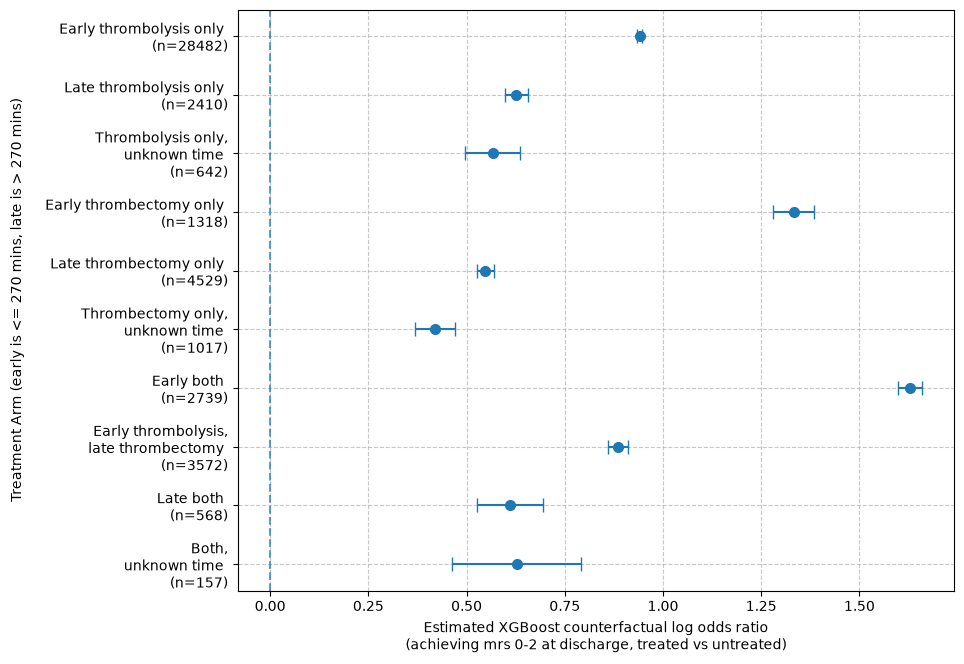

In [18]:
rename_dict = {
    "early_thrombolysis_only": "Early thrombolysis only",
    "late_thrombolysis_only": "Late thrombolysis only",
    "thrombolysis_only_unknown_time": "Thrombolysis only,\nunknown time",
    "early_thrombectomy_only": "Early thrombectomy only",
    "late_thrombectomy_only": "Late thrombectomy only",
    "thrombectomy_only_unknown_time": "Thrombectomy only,\nunknown time",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both",
    "both_unknown_time": "Both,\nunknown time"
}
# Add n values to the y tick labels
n_values = counter_factual_summary["count"].astype(int).to_dict()
rename_dict = {k: f"{v} \n(n={n_values.get(k, 0)})" for k, v in rename_dict.items()}

fig, ax = plt.subplots(figsize=(10, 7))
# Plot the mean prob shift with error bars for 95% CI
ax.errorbar(
    y=range(len(counter_factual_summary_log_odds.index) - 1, -1, -1),
    x=counter_factual_summary_log_odds["mean"],
    xerr=[
        counter_factual_summary_log_odds["mean"] - counter_factual_summary_log_odds["95% CI lower"],
        counter_factual_summary_log_odds["95% CI upper"] - counter_factual_summary_log_odds["mean"],
    ],
    fmt="o",
    markersize=7,  # increase point size
    capsize=5,
    label="Estimated CATE with 95% CI",
)

# Add y tick labels for treatment arms
ax.set_yticks(range(len(counter_factual_summary.index) - 1, -1, -1))
# For y tick labels repolace _ with space
ax.set_yticklabels([rename_dict.get(label, label.replace('_', ' ')) for label in counter_factual_summary_log_odds.index])
# Label the axes
ax.set_xlabel(f"Estimated XGBoost counterfactual log odds ratio\n(achieving mrs 0-{mrs_target} at discharge, treated vs untreated)")
ax.set_ylabel(f"Treatment Arm (early is <= {CUTOFF} mins, late is > {CUTOFF} mins)", labelpad=15)
# Add grid lines
ax.grid(axis="both", linestyle="--", alpha=0.7)
# Add a vertical line at x=0
ax.axvline(x=0, linestyle="--", alpha=0.7)
plt.tight_layout(pad=2)
plt.savefig(
    f"./output/{save_prefix}_all_patients_xgboost_counterfactual_log_odds.png",
    dpi=300,
)
plt.show()

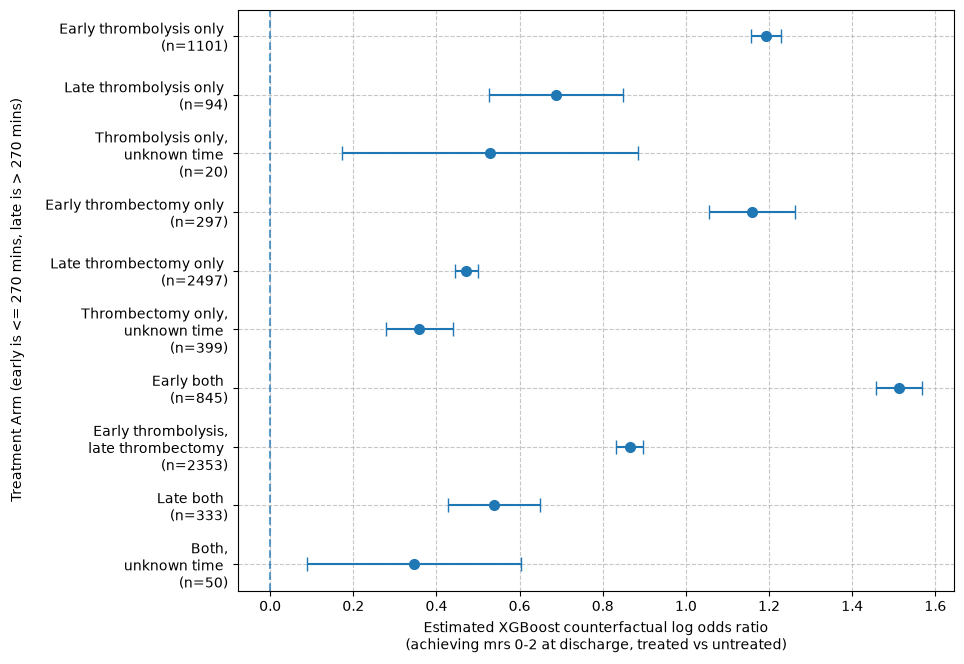

In [19]:
# Filter for transfer patients only
transfer_df = counter_factuals_df[counter_factuals_df["transfer_used"] == 1]

transfer_summary_log_odds = (
    transfer_df.groupby("treatment_group")["log_odds_shift"]
    .agg(["mean", "std", "count"])
)
transfer_summary_log_odds["95% CI lower"] = (
    transfer_summary_log_odds["mean"]
    - 1.96 * transfer_summary_log_odds["std"]
    / np.sqrt(transfer_summary_log_odds["count"])
)
transfer_summary_log_odds["95% CI upper"] = (
    transfer_summary_log_odds["mean"]
    + 1.96 * transfer_summary_log_odds["std"]
    / np.sqrt(transfer_summary_log_odds["count"])
)
transfer_summary_log_odds = (
    transfer_summary_log_odds.reindex(ordered_arms).round(4)
)

rename_dict_transfer = {
    "early_thrombolysis_only": "Early thrombolysis only",
    "late_thrombolysis_only": "Late thrombolysis only",
    "thrombolysis_only_unknown_time": "Thrombolysis only,\nunknown time",
    "early_thrombectomy_only": "Early thrombectomy only",
    "late_thrombectomy_only": "Late thrombectomy only",
    "thrombectomy_only_unknown_time": "Thrombectomy only,\nunknown time",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both",
    "both_unknown_time": "Both,\nunknown time"
}
n_values_transfer = transfer_summary_log_odds["count"].astype(int).to_dict()
rename_dict_transfer = {
    k: f"{v} \n(n={n_values_transfer.get(k, 0)})"
    for k, v in rename_dict_transfer.items()
}

fig, ax = plt.subplots(figsize=(10, 7))
ax.errorbar(
    y=range(len(transfer_summary_log_odds.index) - 1, -1, -1),
    x=transfer_summary_log_odds["mean"],
    xerr=[
        transfer_summary_log_odds["mean"]
        - transfer_summary_log_odds["95% CI lower"],
        transfer_summary_log_odds["95% CI upper"]
        - transfer_summary_log_odds["mean"],
    ],
    fmt="o",
    markersize=7,
    capsize=5,
    label="Estimated CATE with 95% CI",
)
ax.set_yticks(range(len(transfer_summary_log_odds.index) - 1, -1, -1))
ax.set_yticklabels(
    [
        rename_dict_transfer.get(str(label), str(label).replace("_", " "))
        for label in transfer_summary_log_odds.index
    ]
)
ax.set_xlabel(
    f"Estimated XGBoost counterfactual log odds ratio\n"
    f"(achieving mrs 0-{mrs_target} at discharge, treated vs untreated)"
)
ax.set_ylabel(
    f"Treatment Arm (early is <= {CUTOFF} mins, late is > {CUTOFF} mins)",
    labelpad=15,
)
ax.grid(axis="both", linestyle="--", alpha=0.7)
# Add a vertical line at x=0
ax.axvline(x=0, linestyle="--", alpha=0.7)
plt.tight_layout(pad=2)
plt.savefig(
    f"./output/{save_prefix}_transfer_patients_xgboost_counterfactual_log_odds.png",
    dpi=300,
)
plt.show()

## Meta model of benefit

In [20]:
# Remove 'neither' treatment group from the dataset 
counter_factuals_df = counter_factuals_df[counter_factuals_df["treatment_group"] != "neither"]

X = counter_factuals_df[X_fields]
y = counter_factuals_df["log_odds_shift"]

# Ensure categorical features are treated as categorical
for cat_feature in categorical_features:
    X[cat_feature] = X[cat_feature].astype("category")

# Fit XGBoost regression model
model = XGBRegressor(
    enable_categorical=True,
    verbosity=0,
    seed=42,
    eval_metric='rmse'
)
model.fit(X, y)

# Predict log odds shift for the entire dataset
counter_factuals_df["predicted_log_odds_shift"] = model.predict(X)

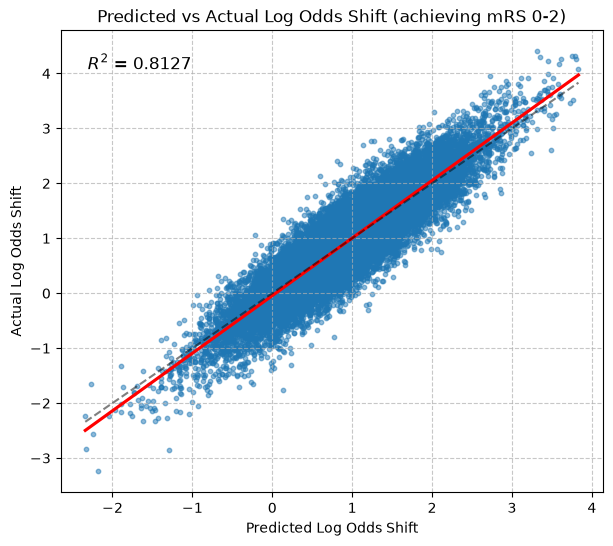

In [21]:
# Plot SEABORN scatter plot with regression line and 95% CI for predicted log odds shift vs actual log odds shift
plt.figure(figsize=(7, 6))
sns.regplot(
    x="predicted_log_odds_shift",
    y="log_odds_shift",
    data=counter_factuals_df,
    ci=95,
    scatter_kws={"s": 10, "alpha": 0.5},
    line_kws={"color": "red"},
)
# Add a line at y=x
plt.plot([counter_factuals_df["predicted_log_odds_shift"].min(), counter_factuals_df["predicted_log_odds_shift"].max()],
         [counter_factuals_df["predicted_log_odds_shift"].min(), counter_factuals_df["predicted_log_odds_shift"].max()],
         color='black', linestyle='--', alpha=0.5)
plt.title(f"Predicted vs Actual Log Odds Shift (achieving mRS 0-{mrs_target})")
plt.xlabel("Predicted Log Odds Shift")
plt.ylabel("Actual Log Odds Shift")
# Add grid lines
plt.grid(axis="both", linestyle="--", alpha=0.7)
# Add r-squared value to the plot
r_squared = model.score(X, y)
plt.text(0.05, 0.95, f"$R^2$ = {r_squared:.4f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.savefig(f"./output/{save_prefix}_regression_log_odds_shift_{mrs_target}.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# Get SHAP values for the S-learner model
explainer = shap.Explainer(model)
shap_values = explainer(X)

<Axes: xlabel='SHAP value (impact on model output)'>

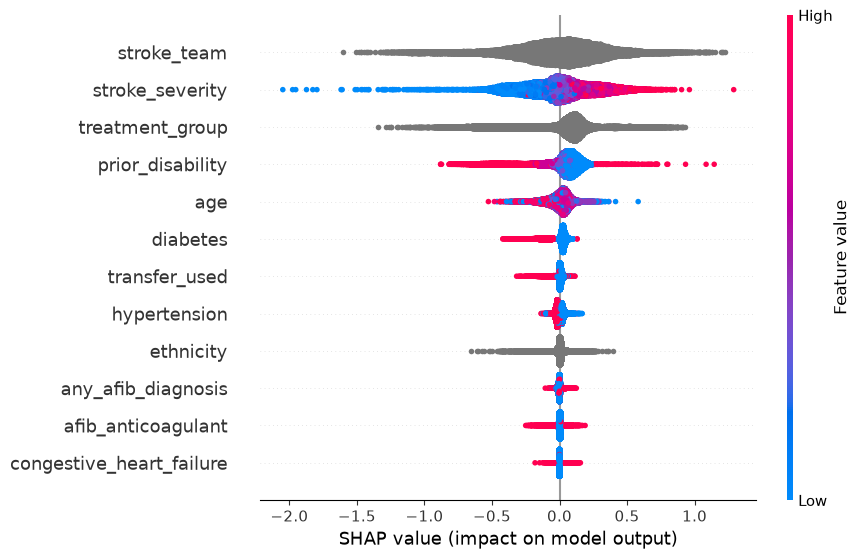

In [23]:
shap.plots.beeswarm(shap_values, max_display=99, show=False)

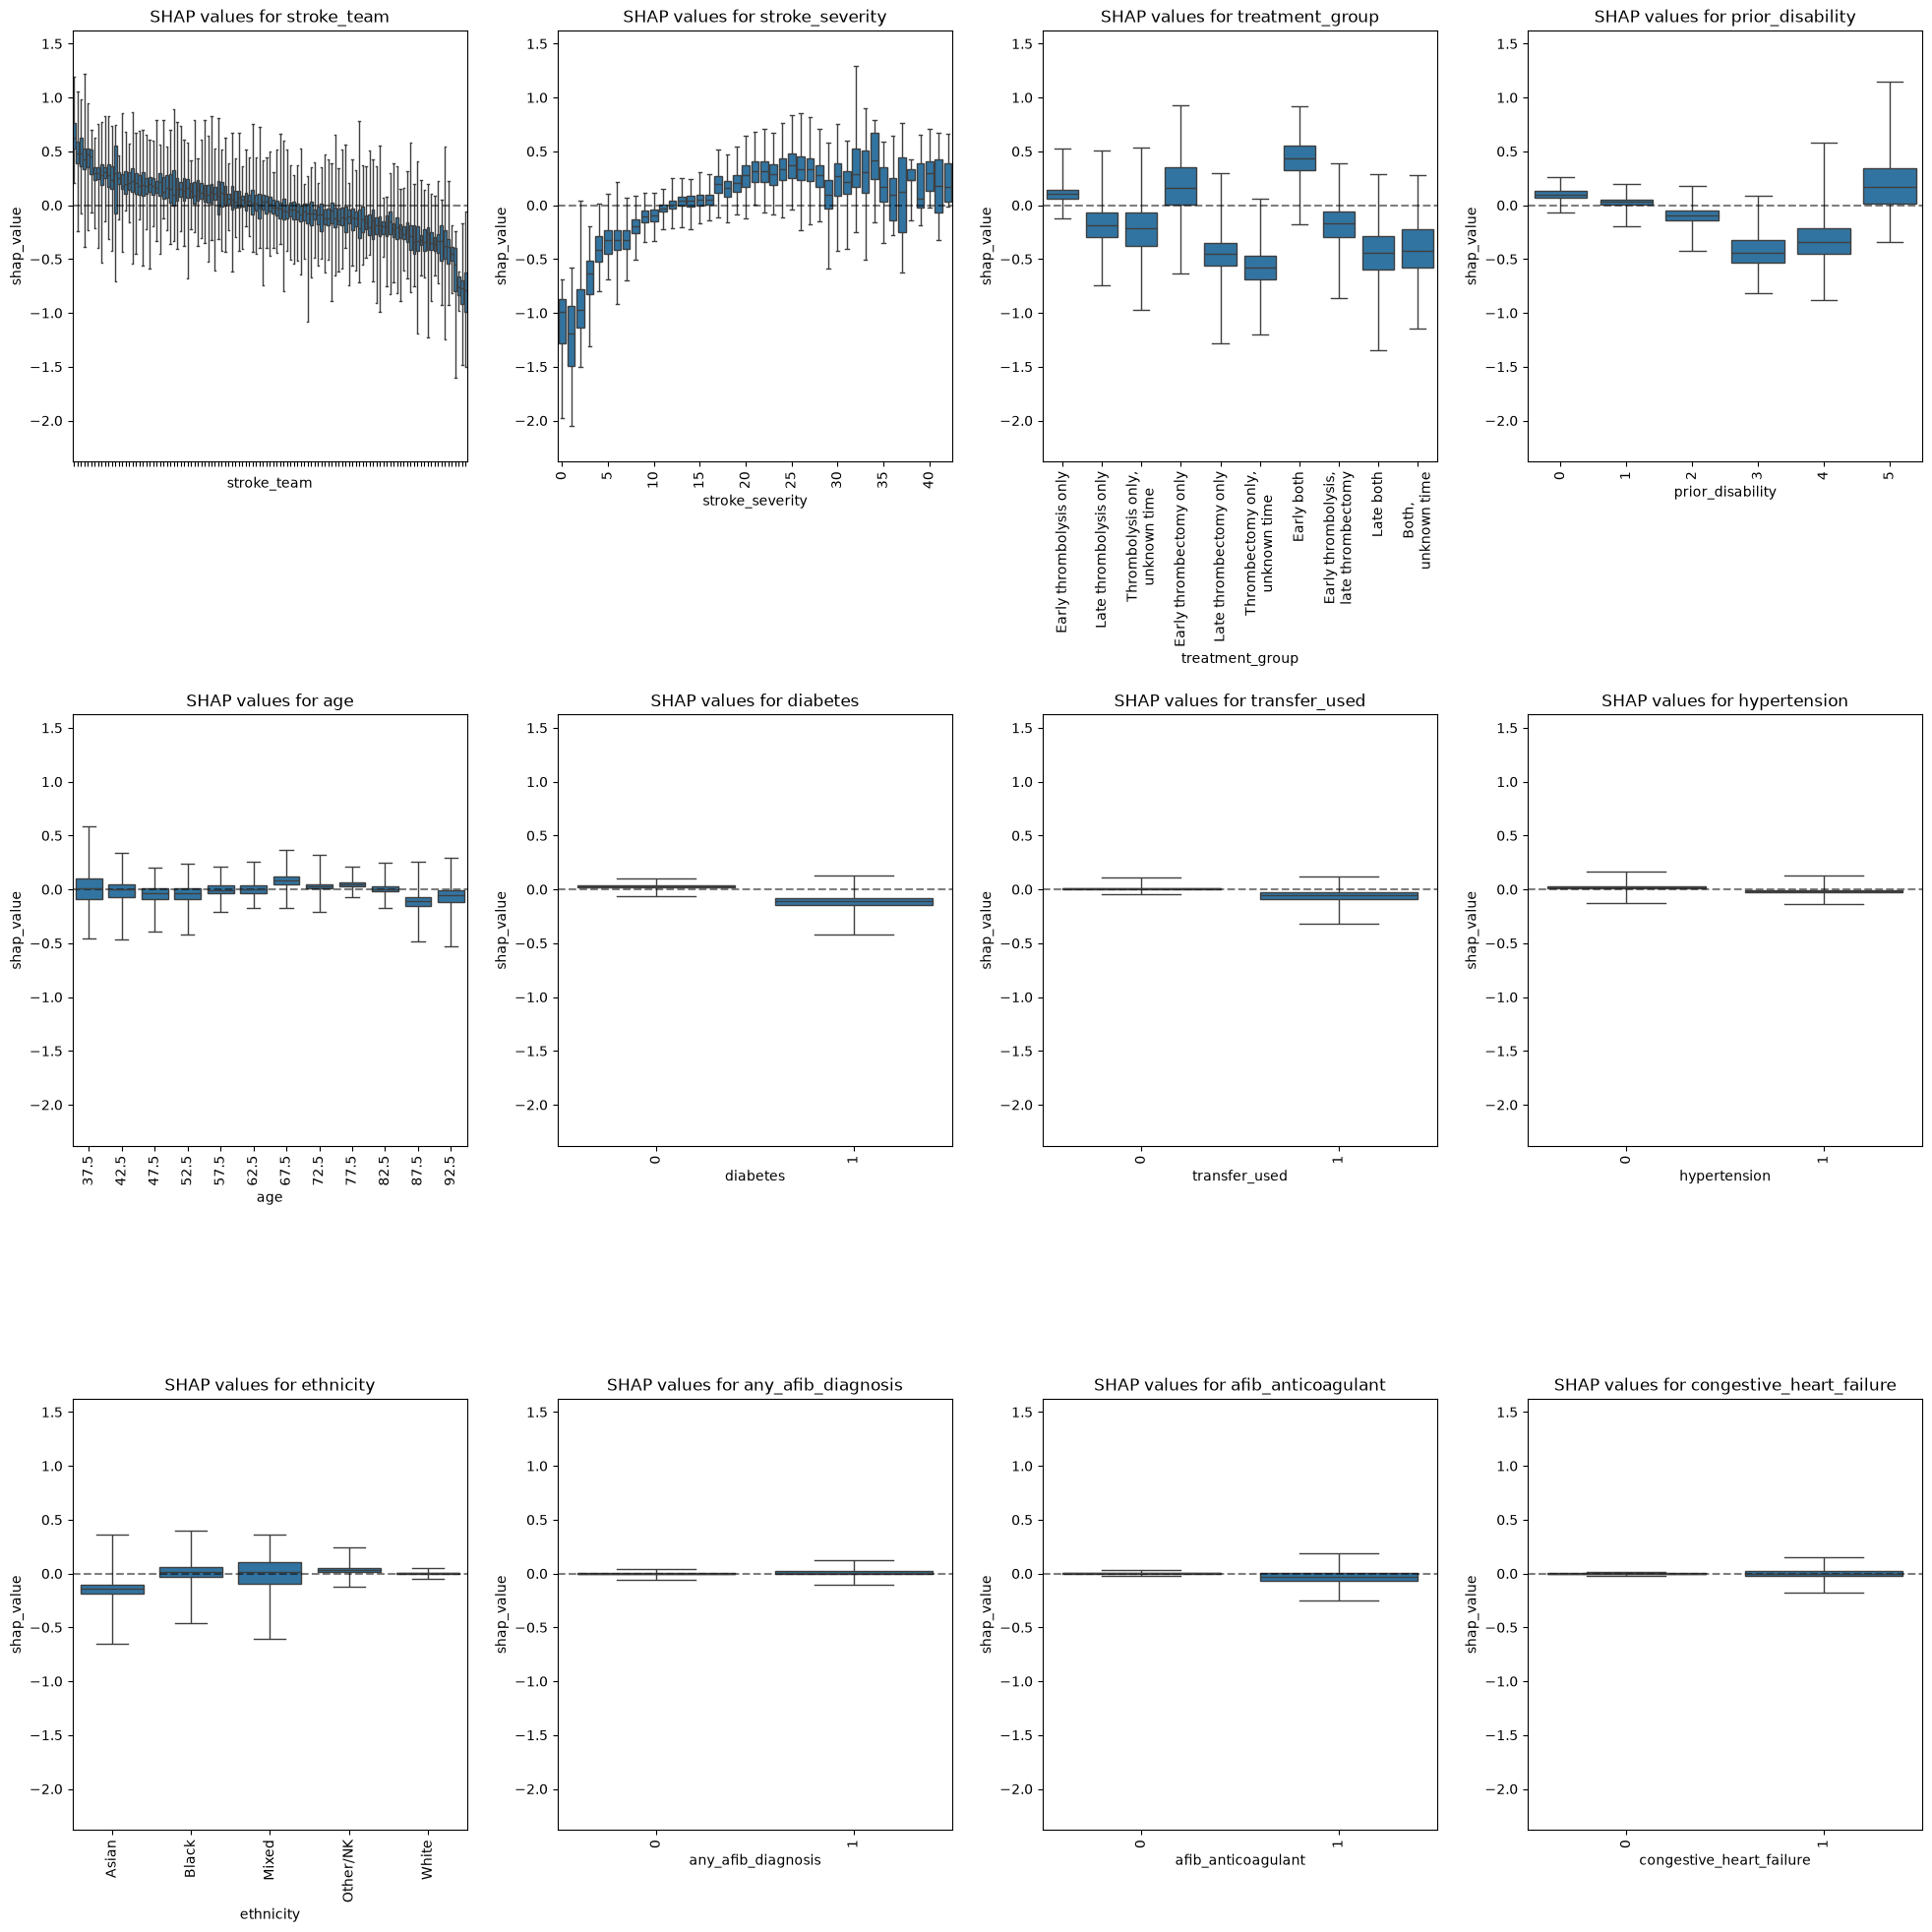

In [24]:
from matplotlib.ticker import FuncFormatter

rename_dict = {
    "early_thrombolysis_only": "Early thrombolysis only",
    "late_thrombolysis_only": "Late thrombolysis only",
    "thrombolysis_only_unknown_time": "Thrombolysis only,\nunknown time",
    "early_thrombectomy_only": "Early thrombectomy only",
    "late_thrombectomy_only": "Late thrombectomy only",
    "thrombectomy_only_unknown_time": "Thrombectomy only,\nunknown time",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both",
    "both_unknown_time": "Both,\nunknown time"
}

features_to_plot = [
    "prior_disability",
    "stroke_severity",
    "age",
    "congestive_heart_failure",
    "hypertension",
    "diabetes",
    "afib_anticoagulant",
    "any_afib_diagnosis",
    "treatment_group",
    "stroke_team",
    "ethnicity",
    "transfer_used"
]

make_int = [
    "prior_disability",
    "stroke_severity",
    "congestive_heart_failure",
    "hypertension",
    "diabetes",
    "afib_anticoagulant",
    "any_afib_diagnosis",
    "transfer_used"
]

# Restrict SHAP values to selected features to avoid shape mismatch
shap_values_selected = shap_values[:, features_to_plot]

# Get average absolute SHAP values for each feature
shap_values_df = pd.DataFrame(
    shap_values_selected.values,
    columns=features_to_plot,
)
mean_abs_shap_values = shap_values_df.abs().mean().sort_values(ascending=False)

# Reorder features based on mean absolute SHAP values
features_to_plot = mean_abs_shap_values.index.tolist()

# Shared y-limits across subplots
min_shap = shap_values_df.min().min()
max_shap = shap_values_df.max().max()
shap_pad = 0.1 * (max_shap - min_shap)

# Create a 3 x 4 grid of SHAP box plots
fig, axes = plt.subplots(3, 4, figsize=(20, 20))

for i, feature in enumerate(features_to_plot):
    row = i // 4
    col = i % 4

    shap_values_feature = shap_values[:, feature].values
    feature_values = X[feature].values

    plot_df = pd.DataFrame(
        {
            "feature_value": feature_values,
            "shap_value": shap_values_feature,
        }
    )

    if feature == "stroke_team":
        avg_shap_values = (
            plot_df.groupby("feature_value")["shap_value"]
            .mean()
            .sort_values(ascending=False)
        )
        sorted_order = avg_shap_values.index.tolist()
        plot_df["feature_value"] = pd.Categorical(
            plot_df["feature_value"],
            categories=sorted_order,
            ordered=True,
        )

    # Use rename dict to rename treatment_group values for plotting
    if feature == "treatment_group":
        sorted_order = [rename_dict.get(k, k) for k in ordered_arms]
        # Convert to string first to avoid Categorical setitem error
        plot_df["feature_value"] = (
            plot_df["feature_value"].astype(str).map(
                lambda x: rename_dict.get(x, x)
            )
        )
        plot_df["feature_value"] = pd.Categorical(
            plot_df["feature_value"],
            categories=sorted_order,
            ordered=True,
        )

    sns.boxplot(
        x="feature_value",
        y="shap_value",
        data=plot_df,
        ax=axes[row, col],
        whis=(0, 100),
    )
    axes[row, col].set_title(f"SHAP values for {feature}")
    axes[row, col].tick_params(axis="x", rotation=90)

    if feature == "stroke_team":
        axes[row, col].set_xticklabels([])

    if feature == "stroke_severity":
        axes[row, col].set_xticks(range(0, 43, 5))
        axes[row, col].xaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f"{x:.0f}")
        )

    axes[row, col].set_xlabel(feature)
    axes[row, col].axhline(y=0, color="black", linestyle="--", alpha=0.5)
    axes[row, col].set_ylim(min_shap - shap_pad, max_shap + shap_pad)

# Hide any unused subplot axes
for j in range(len(features_to_plot), axes.size):
    axes.flat[j].axis("off")

# If the axis is numerical, and is not age, make integer
for ax in axes.flat:
    if ax.get_xlabel() in make_int:
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}"))

plt.tight_layout(pad=2)
plt.savefig(
    f"./output/{save_prefix}_treatment_shap_box_plots_{mrs_target}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [25]:
# Combine SHAP values with counterfactuals_df for further analysis
shap_values_df_combined = pd.concat(
    [
        counter_factuals_df.reset_index(drop=True),
        shap_values_df.reset_index(drop=True).add_prefix("SHAP_"),
    ],
    axis=1,
)

# Add SHAP base values (expected value) to the combined DataFrame
shap_values_df_combined["SHAP_base_value"] = shap_values.base_values[0]

# Save the combined DataFrame to a CSV file
shap_values_df_combined.to_csv(f"./output/{save_prefix}_counterfactuals_with_shap_values.csv", index=False)

shap_values_df_combined.head()

,prior_disability,stroke_severity,age,congestive_heart_failure,hypertension,diabetes,afib_anticoagulant,any_afib_diagnosis,transfer_used,treatment_group,...,SHAP_congestive_heart_failure,SHAP_hypertension,SHAP_diabetes,SHAP_afib_anticoagulant,SHAP_any_afib_diagnosis,SHAP_treatment_group,SHAP_stroke_team,SHAP_ethnicity,SHAP_transfer_used,SHAP_base_value
0,1.0,13.0,47.5,0.0,0.0,0.0,0.0,1.0,0.0,early_thrombolysis_only,...,0.000413,0.027611,0.041779,0.003767,-0.002047,0.177458,-0.059010,-0.002593,0.014849,0.911548
1,3.0,7.0,92.5,0.0,1.0,0.0,0.0,0.0,0.0,early_thrombolysis_only,...,0.001160,-0.014368,0.021043,-0.000422,-0.004525,0.043903,0.007609,0.007499,0.002070,0.911548
2,1.0,9.0,67.5,0.0,0.0,0.0,0.0,1.0,0.0,early_thrombolysis_only,...,-0.000764,0.024391,0.031989,0.001799,0.013559,0.060541,0.227372,0.006245,0.002774,0.911548
3,0.0,26.0,67.5,0.0,1.0,0.0,0.0,1.0,0.0,early_thrombolysis_only,...,0.002743,-0.014146,0.039323,0.010047,-0.002698,0.127602,0.020181,-0.002585,0.008969,0.911548
4,0.0,13.0,77.5,0.0,1.0,0.0,0.0,1.0,0.0,early_thrombolysis_only,...,-0.000439,-0.008767,0.039084,-0.004324,0.008549,0.083079,0.073518,0.008384,0.014769,0.911548
